# Import Libraries

In [1]:
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
print("All Libraries Loaded")

All Libraries Loaded


# Dataset Path

In [2]:
DATASET_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET"
print("Dataset Loaded")

Dataset Loaded


In [3]:
classes = sorted(os.listdir(os.path.join(DATASET_PATH, "classification/train")))
classes

['glioma', 'meningioma', 'pituitary']

# Count Images

In [4]:
train_count = {}
test_count = {}

for cls in classes:

    train_folder = os.path.join(DATASET_PATH, "Classification/train", cls)
    test_folder = os.path.join(DATASET_PATH, "classification/test", cls)

    train_count[cls] = len(os.listdir(train_folder))
    test_count[cls] = len(os.listdir(test_folder))

df = pd.DataFrame({
    "Train": train_count,
    "Test": test_count
})

df["Total"] = df["Train"] + df["Test"]
print("\nTotal Images =", df["Total"].sum())
df


Total Images = 4793


,Train,Test,Total
glioma,1147,254,1401
meningioma,1329,306,1635
pituitary,1457,300,1757


# Bar Plot

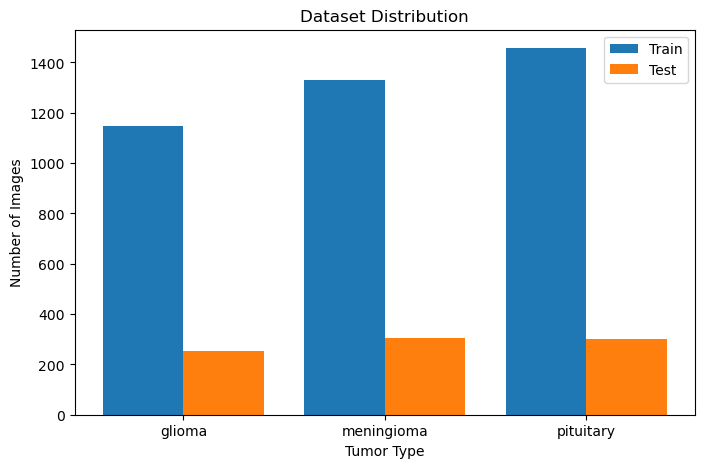

In [5]:
plt.figure(figsize=(8,5))

x = np.arange(len(classes))

plt.bar(x-0.2, df["Train"], width=0.4, label="Train")
plt.bar(x+0.2, df["Test"], width=0.4, label="Test")

plt.xticks(x, classes)

plt.xlabel("Tumor Type")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")
plt.legend()

plt.show()

# DataSet Distribution Over Class

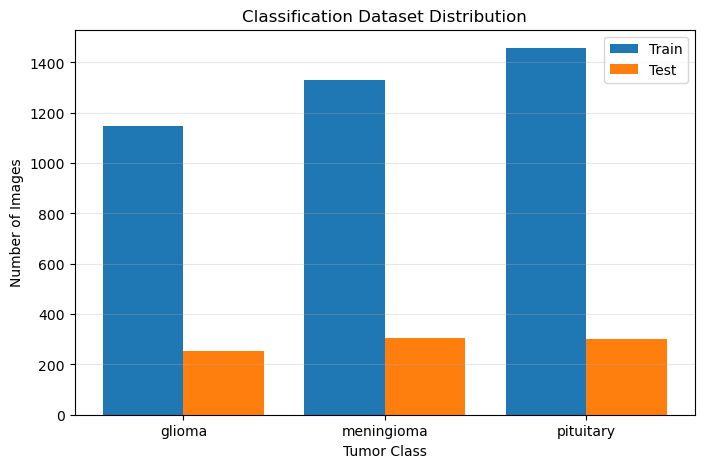

In [6]:
import os
import matplotlib.pyplot as plt

dataset_path = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Classification"

classes = sorted(os.listdir(os.path.join(dataset_path, "train")))

train_counts = []
test_counts = []

for cls in classes:
    train_counts.append(len(os.listdir(os.path.join(dataset_path, "train", cls))))
    test_counts.append(len(os.listdir(os.path.join(dataset_path, "test", cls))))

plt.figure(figsize=(8,5))

x = range(len(classes))

plt.bar([i-0.2 for i in x], train_counts, width=0.4, label="Train")
plt.bar([i+0.2 for i in x], test_counts, width=0.4, label="Test")

plt.xticks(x, classes)

plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.title("Classification Dataset Distribution")

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.show()

# Display Random Image

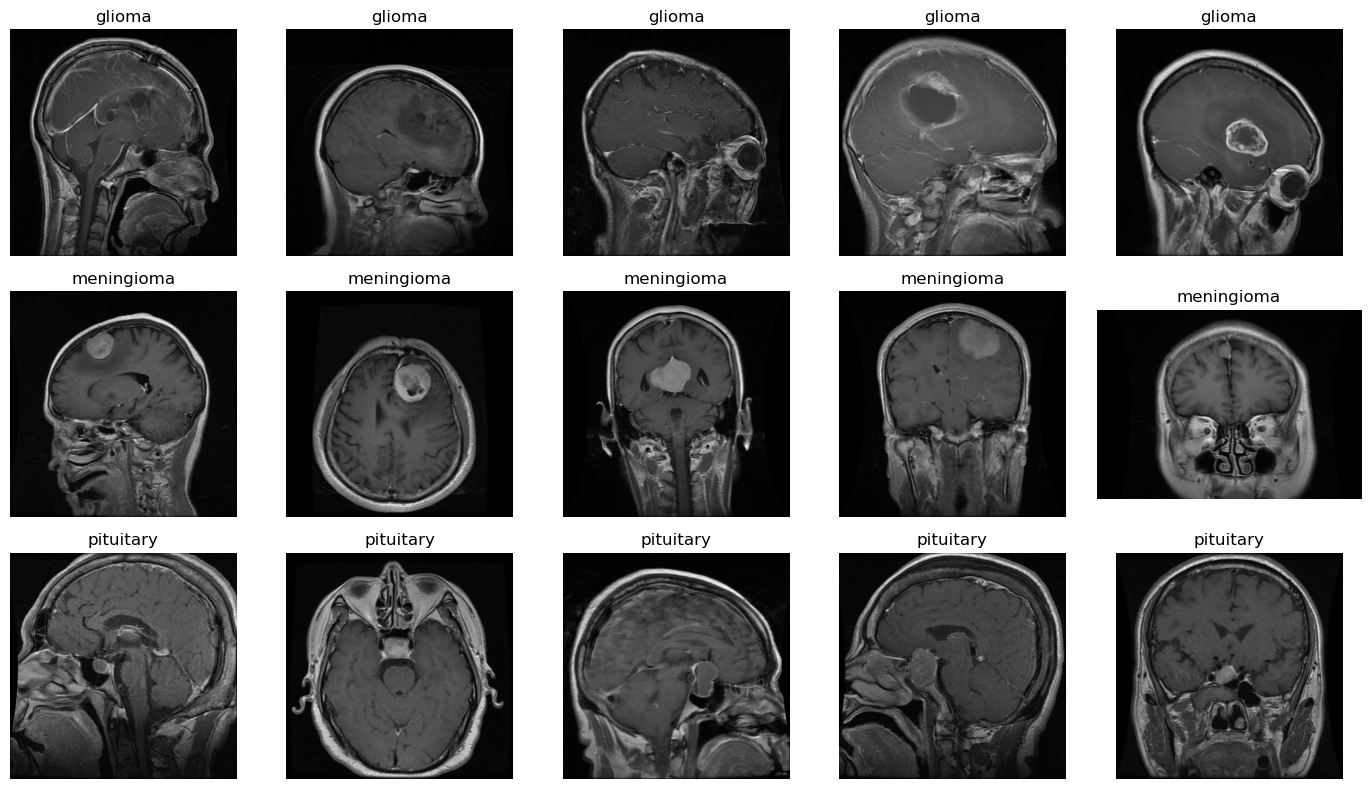

In [7]:
fig, axes = plt.subplots(3,5, figsize=(14,8))

for row, cls in enumerate(classes):

    folder = os.path.join(DATASET_PATH, "classification/train", cls)

    images = random.sample(os.listdir(folder),5)

    for col, img_name in enumerate(images):

        img = cv2.imread(os.path.join(folder,img_name))
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

        axes[row,col].imshow(img)
        axes[row,col].set_title(cls)

        axes[row,col].axis("off")

plt.tight_layout()
plt.show()

# Image Resulution 

In [10]:
sizes = []

for cls in classes:

    folder = os.path.join(DATASET_PATH,"classification/train",cls)

    for img_name in os.listdir(folder):

        img = Image.open(os.path.join(folder,img_name))

        sizes.append(img.size)

size_df = pd.DataFrame(sizes,columns=["Width","Height"])

size_df.head()

,Width,Height
0,512,512
1,512,512
2,512,512
3,512,512
4,512,512


# Check Duplicate Names

In [9]:
all_names = []

for cls in classes:

    folder = os.path.join(DATASET_PATH,"classification/train",cls)

    all_names.extend(os.listdir(folder))

print("Duplicate Names :",len(all_names)-len(set(all_names)))

Duplicate Names : 0


# Complete dataSet Distribution 

In [13]:

# =========================
# Dataset path
# =========================

DATASET_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET"

classes = ["glioma", "meningioma", "pituitary",]

# =========================
# Count images
# =========================

data = []

for cls in classes:

    train_folder = os.path.join(
        DATASET_PATH, "classification", "train", cls
    )

    test_folder = os.path.join(
        DATASET_PATH, "classification", "test", cls
    )

    # Get image files
    train_images = [
        f for f in os.listdir(train_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    test_images = [
        f for f in os.listdir(test_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    train_count = np.size(train_images)
    test_count = np.size(test_images)

    total_count = train_count + test_count

    data.append([
        cls.capitalize(),
        train_count,
        test_count,
        total_count
    ])


# =========================
# Create Pandas DataFrame
# =========================

df = pd.DataFrame(
    data,
    columns=["Class", "Train", "Test", "Total"]
)

# Add total row
total_row = pd.DataFrame({
    "Class": ["Total"],
    "Train": [df["Train"].sum()],
    "Test": [df["Test"].sum()],
    "Total": [df["Total"].sum()]
})

df = pd.concat([df, total_row], ignore_index=True)

print(df)

        Class  Train  Test  Total
0      Glioma   1147   254   1401
1  Meningioma   1329   306   1635
2   Pituitary   1457   300   1757
3       Total   3933   860   4793


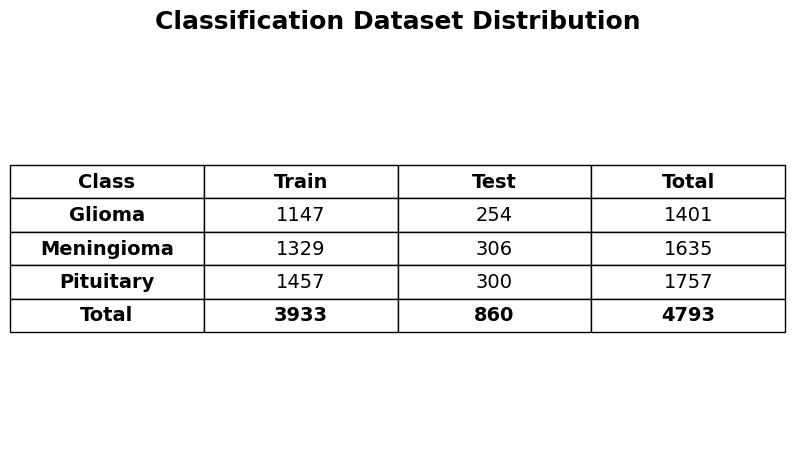

In [15]:
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

ax.axis("off")

# Create table
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc="center",
    loc="center"
)

# Font settings
table.auto_set_font_size(False)
table.set_fontsize(14)

# Increase row height
table.scale(1, 2)

# -------------------------
# Format header
# -------------------------

for col in range(len(df.columns)):
    table[0, col].set_text_props(weight="bold")

# -------------------------
# Format first column
# -------------------------

for row in range(1, len(df) + 1):
    table[row, 0].set_text_props(weight="bold")

# -------------------------
# Format Total row
# -------------------------

total_row = len(df)

for col in range(len(df.columns)):
    table[total_row, col].set_text_props(weight="bold")

# -------------------------
# Title
# -------------------------

plt.title(
    "Classification Dataset Distribution",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# -------------------------
# Save table as image
# -------------------------

plt.savefig(
    "classification_dataset_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()